In [1]:
import numpy as np
from pathlib import Path

alf = Path(r"E:\Aurelien\Data_Mice\VF071_2025_12_18\alf\probe00")

coords = np.load(alf / "channels.localCoordinates.npy")

print("Shape:", coords.shape)
print("Dtype:", coords.dtype)
print("First 10 rows:\n", coords[:10])
print("Min values:", coords.min(axis=0))
print("Max values:", coords.max(axis=0))


Shape: (384, 2)
Dtype: float32
First 10 rows:
 [[16.  0.]
 [48.  0.]
 [ 0. 20.]
 [32. 20.]
 [16. 40.]
 [48. 40.]
 [ 0. 60.]
 [32. 60.]
 [16. 80.]
 [48. 80.]]
Min values: [0. 0.]
Max values: [  48. 3820.]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

alf_probe = Path(r"E:\Aurelien\Data_Mice\VF071_2025_12_18\alf\probe00")

ALF probe folder: E:\Aurelien\Data_Mice\VF071_2025_12_18\alf\probe00

[Geometry]
  geom shape: (384, 2)
  Y min/max: 0.0 3820.0

[Spikes depths]
  depths shape: (11325661,)
  depths min/max: 0.0 3820.00048828125

[Check]
  depth range ~ geometry Y range ? YES

[Conclusion]
  spikes.depths uses the same coordinate system as channels.localCoordinates[:,1].
  In most NP/IBL pipelines: Y=0 corresponds to the TOP of the probe shank,
  and Y max (~3800-4000) corresponds to the TIP.
  => depth=0 is very likely PROBE TOP, not tip.


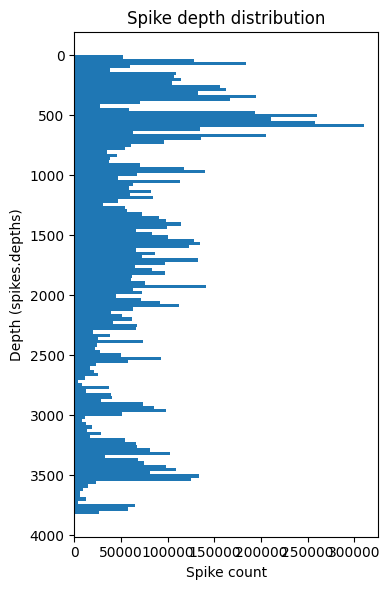

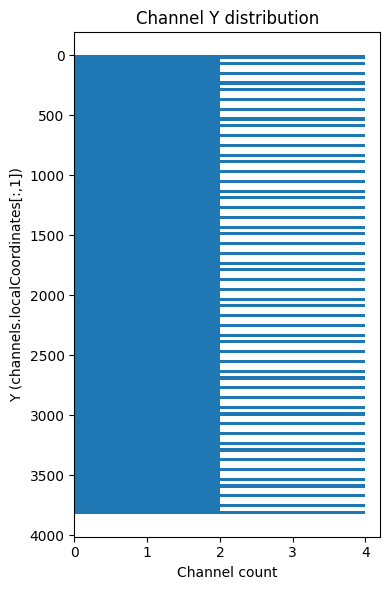

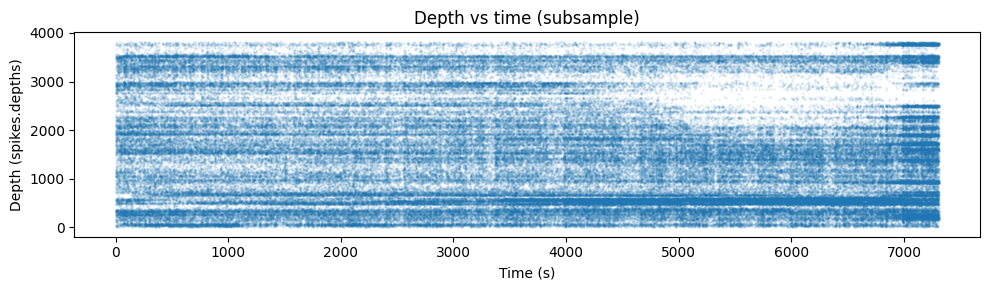

In [4]:
# ============================================================
# Determine whether depth=0 is at probe tip or probe top
# (copy-paste ready)
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0) SET THIS PATH (IMPORTANT)
# ------------------------------------------------------------
# Point this to the ALF probe folder that contains:
#   spikes.depths.npy, spikes.times.npy, spikes.clusters.npy,
#   channels.localCoordinates.npy (or channels.localCoordinates.npy),
#   clusters.labels.csv
#
# Examples:
# alf_probe = Path(r"D:\Data_Mice\VF069_2025_12_06\alf\probe00")
# alf_probe = Path(r"E:\Aurelien\some_session\alf\probe01")


# ------------------------------------------------------------
# 1) Utility: load with fallback filenames
# ------------------------------------------------------------
def load_first_existing(folder: Path, candidates: list[str]) -> np.ndarray:
    for name in candidates:
        p = folder / name
        if p.exists():
            return np.load(p, mmap_mode="r")
    raise FileNotFoundError(
        "None of these files exist in:\n"
        f"  {folder}\n"
        "Tried:\n  - " + "\n  - ".join(candidates)
    )


# ------------------------------------------------------------
# 2) Load geometry + spikes depths
# ------------------------------------------------------------
geom = load_first_existing(
    alf_probe,
    [
        "channels.localCoordinates.npy",
        "channels.local_coordinates.npy",
        "channel.localCoordinates.npy",
        "channel_local_coordinates.npy",
        "channel_localCoordinates.npy",
        "channel_local_coordinates.npy",
    ],
)

depths = load_first_existing(
    alf_probe,
    [
        "spikes.depths.npy",
        "spikes.depth.npy",
    ],
)

# Optional: spike times for a small sanity plot
times = None
try:
    times = load_first_existing(alf_probe, ["spikes.times.npy", "spikes.time.npy"])
except Exception:
    times = None


# ------------------------------------------------------------
# 3) Print basic ranges
# ------------------------------------------------------------
y = np.asarray(geom)[:, 1].astype(float)
y = y[np.isfinite(y)]
d = np.asarray(depths).astype(float)
d = d[np.isfinite(d)]

print("ALF probe folder:", alf_probe)
print("\n[Geometry]")
print("  geom shape:", geom.shape)
print("  Y min/max:", float(y.min()), float(y.max()))

print("\n[Spikes depths]")
print("  depths shape:", depths.shape)
print("  depths min/max:", float(d.min()), float(d.max()))

# Compare scales
scale_match = (abs(d.min() - y.min()) < 50) and (abs(d.max() - y.max()) < 200)
print("\n[Check]")
print("  depth range ~ geometry Y range ?", "YES" if scale_match else "NO / UNCLEAR")


# ------------------------------------------------------------
# 4) Decide: where is depth=0 likely located?
# ------------------------------------------------------------
# For Neuropixels / IBL-like conventions:
#  - localCoordinates Y=0 is almost always the TOP of the shank
#  - Y max (~3800-4000) is near the TIP
#
# So if spikes.depths matches geometry Y, then:
#  - depth=0 -> TOP, not TIP

if scale_match:
    print("\n[Conclusion]")
    print("  spikes.depths uses the same coordinate system as channels.localCoordinates[:,1].")
    print("  In most NP/IBL pipelines: Y=0 corresponds to the TOP of the probe shank,")
    print("  and Y max (~3800-4000) corresponds to the TIP.")
    print("  => depth=0 is very likely PROBE TOP, not tip.")
else:
    print("\n[Conclusion]")
    print("  Depth range does not clearly match geometry Y range.")
    print("  Your pipeline might be using a different depth convention.")
    print("  Use the plots below to infer where activity drops off (often near the tip).")


# ------------------------------------------------------------
# 5) Visual diagnostics (very helpful)
# ------------------------------------------------------------
# A) Spike count vs depth (where it drops is often near the tip)
plt.figure(figsize=(4, 6))
plt.hist(d, bins=140, orientation="horizontal")
plt.gca().invert_yaxis()
plt.xlabel("Spike count")
plt.ylabel("Depth (spikes.depths)")
plt.title("Spike depth distribution")
plt.tight_layout()
plt.show()

# B) Geometry: channel density along Y (for context)
plt.figure(figsize=(4, 6))
plt.hist(y, bins=140, orientation="horizontal")
plt.gca().invert_yaxis()
plt.xlabel("Channel count")
plt.ylabel("Y (channels.localCoordinates[:,1])")
plt.title("Channel Y distribution")
plt.tight_layout()
plt.show()

# C) Optional: if times are available, show depth over time (random subsample)
if times is not None:
    t = np.asarray(times).astype(float)
    ok = np.isfinite(t) & np.isfinite(np.asarray(depths).astype(float))
    t = t[ok]
    d2 = np.asarray(depths).astype(float)[ok]

    # subsample for speed
    if t.size > 200_000:
        rng = np.random.default_rng(0)
        idx = rng.choice(t.size, size=200_000, replace=False)
        t = t[idx]
        d2 = d2[idx]

    plt.figure(figsize=(10, 3))
    plt.scatter(t, d2, s=1, alpha=0.08)
    plt.xlabel("Time (s)")
    plt.ylabel("Depth (spikes.depths)")
    plt.title("Depth vs time (subsample)")
    plt.tight_layout()
    plt.show()
